# 05 Neural network

In [1]:
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import functional_call
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score, roc_curve
from sklearn.preprocessing import QuantileTransformer

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(DEVICE)

mps


In [2]:
def load(part):
    transaction = pd.read_csv(f"../data/raw/{part}_transaction.csv")
    identity = pd.read_csv(f"../data/raw/{part}_identity.csv")
    identity.columns = identity.columns.str.replace("-", "_")
    df = transaction.merge(identity, on="TransactionID", how="left", indicator=True)
    df["has_identity"] = (df.pop("_merge") == "both").astype(int)
    floats = df.select_dtypes("float64").columns
    df[floats] = df[floats].astype(np.float32)
    return df


df = pd.concat([load("train"), load("test")], ignore_index=True)
is_test = df["isFraud"].isna().to_numpy()
train_idx = np.flatnonzero(~is_test)
test_idx = np.flatnonzero(is_test)
y = df.loc[train_idx, "isFraud"].astype(int).to_numpy()
dt = df["TransactionDT"].to_numpy()
base_rate = y.mean()

print("train:", len(train_idx), "test:", len(test_idx), "fraud rate:", round(base_rate, 4))

train: 590540 test: 506691 fraud rate: 0.035


## Features

In [3]:
day = df["TransactionDT"] // 86400
hour = df["TransactionDT"] // 3600 % 24
raw_features = [c for c in df.columns if c not in ["TransactionID", "TransactionDT", "isFraud", "has_identity"]]

basic = pd.DataFrame({
    "amt_cents": df["TransactionAmt"] % 1,
    "hour_sin": np.sin(2 * np.pi * hour / 24),
    "hour_cos": np.cos(2 * np.pi * hour / 24),
    "nan_count": df[raw_features].isna().sum(axis=1),
})

freq = pd.DataFrame()
for col in ["card1", "card2", "card3", "card5", "addr1", "addr2",
            "P_emaildomain", "R_emaildomain", "DeviceInfo", "id_31"]:
    values = df[col].astype(str)
    freq[col + "_freq"] = values.map(values.value_counts())


def split_family_version(s):
    s = s.str.lower()
    version = pd.to_numeric(s.str.extract(r"(\d+(?:[._]\d+)?)")[0].str.replace("_", "."), errors="coerce")
    family = s.str.replace(r"\s*\d.*$", "", regex=True).str.strip()
    return family, version


browser_family, browser_version = split_family_version(df["id_31"])
os_family, os_version = split_family_version(df["id_30"])
parsed = pd.DataFrame({
    "browser_family": browser_family,
    "browser_version": browser_version,
    "os_family": os_family,
    "os_version": os_version,
})
parsed["browser_version_lag"] = parsed.groupby("browser_family")["browser_version"].cummax() - parsed["browser_version"]

uid = df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_" + (day - df["D1"]).astype(str)
grp = df.groupby(uid)
client = pd.DataFrame({
    "uid_count": grp["TransactionID"].transform("size"),
    "uid_amt_mean": grp["TransactionAmt"].transform("mean"),
    "uid_amt_std": grp["TransactionAmt"].transform("std"),
    "uid_D15_mean": grp["D15"].transform("mean"),
    "uid_C13_mean": grp["C13"].transform("mean"),
    "uid_dist1_mean": grp["dist1"].transform("mean"),
    "uid_email_nunique": grp["P_emaildomain"].transform("nunique"),
    "uid_device_nunique": grp["DeviceInfo"].transform("nunique"),
    "uid_days_active": (grp["TransactionDT"].transform("max") - grp["TransactionDT"].transform("min")) / 86400,
})
client["amt_to_uid_mean"] = df["TransactionAmt"] / client["uid_amt_mean"]

data = pd.concat([df, basic, freq, parsed, client], axis=1)

In [4]:
id_num = [c for c in raw_features if c.startswith("id_") and pd.api.types.is_numeric_dtype(df[c])]
id_cat = [c for c in raw_features if c.startswith("id_") and c not in id_num + ["id_30", "id_31"]]

num_cols = (["TransactionAmt", "has_identity"] + [f"C{i}" for i in range(1, 15)]
            + [f"D{i}" for i in range(1, 16)] + ["dist1", "dist2"] + id_num
            + ["V258", "V187", "V200", "V317", "V257", "V70"]
            + list(basic.columns) + list(freq.columns)
            + ["browser_version", "os_version", "browser_version_lag"] + list(client.columns))
cat_cols = (["ProductCD", "card1", "card2", "card3", "card4", "card5", "card6", "addr1", "addr2",
             "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"]
            + [f"M{i}" for i in range(1, 10)] + id_cat + ["browser_family", "os_family"])

print("numeric:", len(num_cols), "categorical:", len(cat_cols))

numeric: 89 categorical: 37


In [5]:
num_raw = data[num_cols].to_numpy(np.float32)

qt = QuantileTransformer(n_quantiles=1000, output_distribution="normal", subsample=200_000, random_state=42)
qt.fit(num_raw[train_idx])
num_q = qt.transform(num_raw).astype(np.float32)

missing = np.isnan(num_q)
miss_share = missing[train_idx].mean(axis=0)
flag_cols = np.flatnonzero((miss_share > 0.005) & (miss_share < 0.995))
num_all = np.hstack([np.nan_to_num(num_q), missing[:, flag_cols]]).astype(np.float32)

print("numeric inputs:", num_all.shape[1], "=", len(num_cols), "values +", len(flag_cols), "flags")
print("TransactionAmt skew before:", round(pd.Series(num_raw[train_idx, 0]).skew(), 1))
print("TransactionAmt skew after:", round(pd.Series(num_all[train_idx, 0]).skew(), 2))

numeric inputs: 139 = 89 values + 50 flags
TransactionAmt skew before: 14.4
TransactionAmt skew after: -0.0


In [6]:
def emb_dim(n):
    return int(min(32, round(1.6 * n ** 0.56)))


cat_codes = []
cardinalities = []
for col in cat_cols:
    values = data[col]
    counts = values.iloc[train_idx].value_counts()
    vocab = {v: i + 2 for i, v in enumerate(counts[counts >= 20].index)}
    codes = values.map(vocab).fillna(1).to_numpy()
    codes[data[col].isna().to_numpy()] = 0
    cat_codes.append(codes)
    cardinalities.append(len(vocab) + 2)

cat_all = np.stack(cat_codes, axis=1).astype(np.int64)

vocab_table = pd.DataFrame({
    "values": [data[c].nunique() for c in cat_cols],
    "vocabulary": cardinalities,
    "embedding dim": [emb_dim(n) for n in cardinalities],
    "test rare/unseen": (cat_all[test_idx] == 1).mean(axis=0),
}, index=cat_cols)
print("total embedding size:", vocab_table["embedding dim"].sum())
vocab_table.sort_values("vocabulary", ascending=False).head(8).round(3)

total embedding size: 298


,values,vocabulary,embedding dim,test rare/unseen
card1,17091,2637,32,0.111
card2,501,500,32,0.001
DeviceInfo,2799,313,32,0.047
addr1,441,87,20,0.002
id_33,461,64,16,0.006
P_emaildomain,60,61,16,0.000
card5,138,59,16,0.001
R_emaildomain,60,57,15,0.000


In [7]:
XN = torch.tensor(num_all, device=DEVICE)
XC = torch.tensor(cat_all, device=DEVICE)
Y = torch.tensor(y, dtype=torch.float32, device=DEVICE)

PRODUCT_POS = cat_cols.index("ProductCD")
N_PRODUCTS = cardinalities[PRODUCT_POS]
product = df.loc[train_idx, "ProductCD"].to_numpy()
amount = df.loc[train_idx, "TransactionAmt"].to_numpy()
transaction_id = df["TransactionID"].to_numpy()

del df, data, num_raw, num_q, missing
print(XN.shape, XC.shape)

torch.Size([1097231, 139]) torch.Size([1097231, 37])


## Custom layers

In [8]:
class CrossLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(dim, dim) / dim)
        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, x0, x):
        return x0 * (x @ self.weight.T + self.bias) + x

In [9]:
torch.manual_seed(0)
cross = CrossLayer(5).double()
x0 = torch.randn(3, 5, dtype=torch.float64, requires_grad=True)
x = torch.randn(3, 5, dtype=torch.float64, requires_grad=True)
w = cross.weight.detach().clone().requires_grad_(True)
b = cross.bias.detach().clone().requires_grad_(True)
print("CrossLayer gradcheck:", torch.autograd.gradcheck(
    lambda x0, x, w, b: functional_call(cross, {"weight": w, "bias": b}, (x0, x)), (x0, x, w, b)))
print("CrossLayer = formula:", torch.allclose(cross(x0, x), x0 * (x @ w.T + b) + x))

CrossLayer gradcheck: True
CrossLayer = formula: True


In [10]:
class ProductFiLM(nn.Module):
    def __init__(self, n_products, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(n_products, dim))
        self.beta = nn.Parameter(torch.zeros(n_products, dim))

    def forward(self, h, product):
        return h * (1 + self.gamma[product]) + self.beta[product]

In [11]:
film = ProductFiLM(4, 5).double()
h = torch.randn(6, 5, dtype=torch.float64, requires_grad=True)
prod = torch.tensor([0, 1, 2, 3, 1, 0])
gamma = (0.1 * torch.randn(4, 5, dtype=torch.float64)).requires_grad_(True)
beta = (0.1 * torch.randn(4, 5, dtype=torch.float64)).requires_grad_(True)
print("ProductFiLM gradcheck:", torch.autograd.gradcheck(
    lambda h, g, b: functional_call(film, {"gamma": g, "beta": b}, (h, prod)), (h, gamma, beta)))
print("ProductFiLM is identity at start:", torch.equal(film(h, prod), h))

ProductFiLM gradcheck: True
ProductFiLM is identity at start: True


## Optimizer

In [12]:
class RAdamW(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2, rectify=True):
        defaults = {"lr": lr, "betas": betas, "eps": eps, "weight_decay": weight_decay, "rectify": rectify}
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            rho_inf = 2 / (1 - beta2) - 1
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad

                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p)
                    state["v"] = torch.zeros_like(p)
                state["step"] += 1
                t = state["step"]

                p.mul_(1 - group["lr"] * group["weight_decay"])
                state["m"].mul_(beta1).add_(g, alpha=1 - beta1)
                state["v"].mul_(beta2).addcmul_(g, g, value=1 - beta2)

                bias1 = 1 - beta1 ** t
                bias2 = 1 - beta2 ** t
                m_hat = state["m"] / bias1

                if not group["rectify"]:
                    v_hat = state["v"] / bias2
                    p.add_(-group["lr"] * m_hat / (v_hat.sqrt() + group["eps"]))
                    continue

                rho_t = rho_inf - 2 * t * beta2 ** t / bias2
                if rho_t > 5:
                    l_t = math.sqrt(bias2) / (state["v"].sqrt() + group["eps"])
                    r_t = math.sqrt((rho_t - 4) * (rho_t - 2) * rho_inf / ((rho_inf - 4) * (rho_inf - 2) * rho_t))
                    p.add_(-group["lr"] * r_t * l_t * m_hat)
                else:
                    p.add_(-group["lr"] * m_hat)

In [13]:
def run_optimizer(opt_class, **kwargs):
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(10, 16), nn.ReLU(), nn.Linear(16, 1))
    opt = opt_class(net.parameters(), lr=1e-2, weight_decay=0.1, **kwargs)
    gen = torch.Generator().manual_seed(1)
    for _ in range(200):
        xb = torch.randn(32, 10, generator=gen)
        target = (xb[:, 0] + 0.5 * xb[:, 1] > 0).float()
        loss = F.binary_cross_entropy_with_logits(net(xb).squeeze(1), target)
        opt.zero_grad()
        loss.backward()
        opt.step()
    params = torch.cat([p.detach().flatten() for p in net.parameters()])
    return params, loss.item()


ours_adamw, loss_adamw = run_optimizer(RAdamW, rectify=False)
torch_adamw, _ = run_optimizer(torch.optim.AdamW)
ours_radam, loss_radam = run_optimizer(RAdamW)
torch_radam, _ = run_optimizer(torch.optim.RAdam, decoupled_weight_decay=True)

print("rectify=False vs torch AdamW, max difference:", (ours_adamw - torch_adamw).abs().max().item())
print("rectify=True vs torch RAdam, max difference:", (ours_radam - torch_radam).abs().max().item())
print("final loss: AdamW", round(loss_adamw, 4), "| RAdamW", round(loss_radam, 4))

rectify=False vs torch AdamW, max difference: 4.76837158203125e-07
rectify=True vs torch RAdam, max difference: 2.980232238769531e-07
final loss: AdamW 0.0551 | RAdamW 0.2617


Both modes of `RAdamW` match PyTorch's AdamW and RAdam.

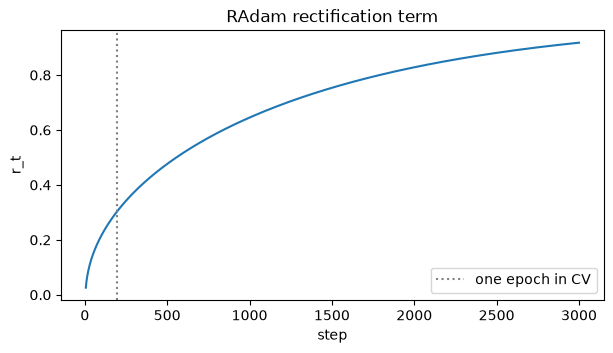

In [14]:
beta2 = 0.999
rho_inf = 2 / (1 - beta2) - 1
t = np.arange(1, 3001)
rho_t = rho_inf - 2 * t * beta2 ** t / (1 - beta2 ** t)
r_t = np.full(len(t), np.nan)
ok = rho_t > 5
r_t[ok] = np.sqrt((rho_t[ok] - 4) * (rho_t[ok] - 2) * rho_inf / ((rho_inf - 4) * (rho_inf - 2) * rho_t[ok]))

plt.figure(figsize=(7, 3.5))
plt.plot(t, r_t)
plt.axvline(len(train_idx) * 0.75 * 0.9 / 2048, color="gray", ls=":", label="one epoch in CV")
plt.xlabel("step")
plt.ylabel("r_t")
plt.title("RAdam rectification term")
plt.legend()
plt.show()

## Model

In [15]:
class FraudNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embeddings = nn.ModuleList([nn.Embedding(n, emb_dim(n)) for n in cardinalities])
        self.emb_dropout = nn.Dropout(0.1)
        d_in = XN.shape[1] + sum(emb_dim(n) for n in cardinalities)
        h1, h2 = cfg["hidden"]

        self.fc1 = nn.Linear(d_in, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.film = ProductFiLM(N_PRODUCTS, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop = nn.Dropout(cfg["dropout"])
        self.deep_head = nn.Linear(h2, 1)

        self.cross = nn.ModuleList([CrossLayer(d_in), CrossLayer(d_in)])
        self.cross_norm = nn.LayerNorm(d_in)
        self.cross_head = nn.Linear(d_in, 1)

        self.head = nn.Linear(h2 + (d_in if cfg["use_cross"] else 0), 1)

        if cfg["init"] != "default":
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    if cfg["init"] == "he":
                        nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                    else:
                        nn.init.xavier_uniform_(m.weight)
                    nn.init.zeros_(m.bias)

        prior = math.log(base_rate / (1 - base_rate))
        for layer in [self.head, self.deep_head, self.cross_head]:
            nn.init.constant_(layer.bias, prior)

    def forward(self, xn, xc):
        emb = torch.cat([e(xc[:, i]) for i, e in enumerate(self.embeddings)], dim=1)
        x0 = torch.cat([xn, self.emb_dropout(emb)], dim=1)

        h = self.bn1(self.fc1(x0))
        if self.cfg["use_film"]:
            h = self.film(h, xc[:, PRODUCT_POS])
        h = self.drop(F.relu(h))
        h = self.drop(F.relu(self.bn2(self.fc2(h))))
        out = {"deep": self.deep_head(h).squeeze(1)}

        if self.cfg["use_cross"]:
            c = x0
            for layer in self.cross:
                c = layer(x0, c)
            c = self.cross_norm(c)
            out["cross"] = self.cross_head(c).squeeze(1)
            h = torch.cat([h, c], dim=1)

        out["main"] = self.head(h).squeeze(1)
        return out


def compute_loss(out, target, aux_weight):
    loss = F.binary_cross_entropy_with_logits(out["main"], target)
    if aux_weight > 0:
        aux = [F.binary_cross_entropy_with_logits(out[k], target) for k in ["deep", "cross"] if k in out]
        loss = loss + aux_weight * sum(aux) / len(aux)
    return loss

In [16]:
def make_optimizer(model, cfg):
    groups = {"dense": [], "cross": [], "film": [], "embeddings": [], "other": []}
    for name, p in model.named_parameters():
        if name.startswith("embeddings"):
            groups["embeddings"].append(p)
        elif name.startswith("cross."):
            groups["cross"].append(p)
        elif name.startswith("film"):
            groups["film"].append(p)
        elif p.dim() > 1:
            groups["dense"].append(p)
        else:
            groups["other"].append(p)

    lr = cfg["lr"]
    wd = cfg["weight_decay"]
    slow = lr * cfg["slow_lr"]
    return RAdamW([
        {"params": groups["dense"], "weight_decay": wd},
        {"params": groups["cross"], "weight_decay": wd, "lr": slow},
        {"params": groups["film"], "weight_decay": 0.0, "lr": slow},
        {"params": groups["embeddings"], "weight_decay": wd},
        {"params": groups["other"], "weight_decay": 0.0},
    ], lr=lr, rectify=cfg["rectify"])


BASE_CFG = {"hidden": (256, 128), "dropout": 0.2, "use_cross": False, "use_film": False,
            "aux_weight": 0.0, "lr": 2e-3, "weight_decay": 1e-2, "slow_lr": 1.0,
            "rectify": True, "warmup": True, "init": "default"}
FULL_CFG = {**BASE_CFG, "use_cross": True, "use_film": True, "aux_weight": 0.2}

model = FraudNet(FULL_CFG)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 651570


In [17]:
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(train_idx, 16384, replace=False))
sample = torch.as_tensor(sample_idx, device=DEVICE)
p = y[sample_idx].mean()
entropy = -(p * math.log(p) + (1 - p) * math.log(1 - p))

torch.manual_seed(0)
model = FraudNet(FULL_CFG).to(DEVICE).eval()
with torch.no_grad():
    loss_prior = F.binary_cross_entropy_with_logits(model(XN[sample], XC[sample])["main"], Y[sample]).item()
    nn.init.zeros_(model.head.bias)
    loss_zero = F.binary_cross_entropy_with_logits(model(XN[sample], XC[sample])["main"], Y[sample]).item()

print("fraud rate in sample:", round(p, 4))
print("entropy:", round(entropy, 4))
print("initial loss, prior bias:", round(loss_prior, 4))
print("initial loss, zero bias:", round(loss_zero, 4))

fraud rate in sample: 0.0317
entropy: 0.1407
initial loss, prior bias: 0.1423
initial loss, zero bias: 0.7202


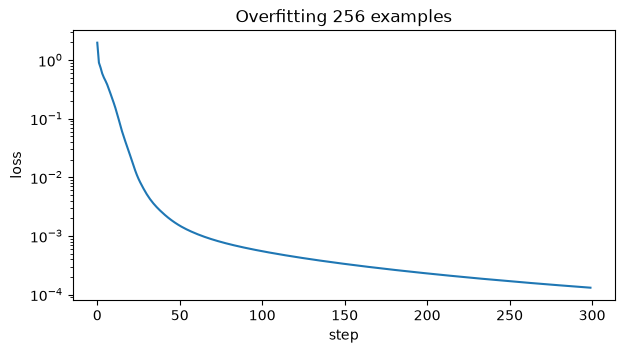

loss: start 1.973 step 100 0.0005 end 0.00013


In [18]:
tiny = np.concatenate([rng.choice(train_idx[y == 1], 128, replace=False),
                       rng.choice(train_idx[y == 0], 128, replace=False)])
tiny = torch.as_tensor(tiny, device=DEVICE)

torch.manual_seed(0)
model = FraudNet({**FULL_CFG, "dropout": 0.0}).to(DEVICE).train()
model.emb_dropout.p = 0.0
opt = RAdamW(model.parameters(), lr=3e-3, weight_decay=0.0, rectify=False)
tiny_losses = []
for step in range(300):
    loss = compute_loss(model(XN[tiny], XC[tiny]), Y[tiny], 0.2)
    opt.zero_grad()
    loss.backward()
    opt.step()
    tiny_losses.append(loss.item())

plt.figure(figsize=(7, 3.5))
plt.plot(tiny_losses)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Overfitting 256 examples")
plt.show()

print("loss: start", round(tiny_losses[0], 3), "step 100", round(tiny_losses[100], 4), "end", round(tiny_losses[-1], 5))

All checks pass: the starting loss equals the entropy, and the model can overfit 256 examples.

## Training

In [19]:
MAX_EPOCHS = 15
PATIENCE = 3
BATCH = 2048

blocks = pd.qcut(dt[train_idx], 4, labels=False)
folds = [(np.flatnonzero(blocks != g), np.flatnonzero(blocks == g)) for g in range(4)]


def make_scheduler(opt, cfg, steps_per_epoch):
    total = MAX_EPOCHS * steps_per_epoch
    if not cfg["warmup"]:
        return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total, eta_min=0.05 * cfg["lr"])
    warmup = torch.optim.lr_scheduler.LinearLR(opt, start_factor=1 / steps_per_epoch, total_iters=steps_per_epoch - 1)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total - steps_per_epoch, eta_min=0.05 * cfg["lr"])
    return torch.optim.lr_scheduler.SequentialLR(opt, [warmup, cosine], milestones=[steps_per_epoch])


def predict(model, idx):
    model.eval()
    preds = []
    with torch.no_grad():
        for s in range(0, len(idx), 16384):
            b = torch.as_tensor(idx[s:s + 16384], device=DEVICE)
            preds.append(torch.sigmoid(model(XN[b], XC[b])["main"]).cpu())
    return torch.cat(preds).numpy()


def logged_step(model, opt, step, epoch, rows, hist):
    params = {n: p for n, p in model.named_parameters() if p.grad is not None}
    before = {n: p.detach().clone() for n, p in params.items()}
    if step % 50 == 0:
        hist.append((step, torch.cat([p.grad.abs().flatten() for p in params.values()]).cpu()))

    opt.step()

    layers = {}
    for n, p in params.items():
        s = layers.setdefault(n.split(".")[0], {"grad": 0.0, "update": 0.0, "weight": 0.0})
        s["grad"] += p.grad.pow(2).sum().item()
        s["update"] += (p.detach() - before[n]).pow(2).sum().item()
        s["weight"] += before[n].pow(2).sum().item()
    for layer, s in layers.items():
        rows.append({"step": step, "epoch": epoch, "layer": layer,
                     "grad norm": math.sqrt(s["grad"]),
                     "update ratio": math.sqrt(s["update"]) / (math.sqrt(s["weight"]) + 1e-12)})


def train_model(cfg, train_idx, es_idx=None, epochs=MAX_EPOCHS, seed=0, log_grads=False):
    torch.manual_seed(seed)
    model = FraudNet(cfg).to(DEVICE)
    opt = make_optimizer(model, cfg)
    steps_per_epoch = math.ceil(len(train_idx) / BATCH)
    sched = make_scheduler(opt, cfg, steps_per_epoch)
    train_t = torch.as_tensor(train_idx, device=DEVICE)
    gen = torch.Generator().manual_seed(seed)

    history = []
    grad_rows = []
    grad_hist = []
    best_auc, best_epoch, best_state, bad = -1, epochs, None, 0
    step = 0
    for epoch in range(epochs):
        model.train()
        perm = train_t[torch.randperm(len(train_idx), generator=gen).to(DEVICE)]
        losses = []
        for s in range(0, len(perm), BATCH):
            b = perm[s:s + BATCH]
            loss = compute_loss(model(XN[b], XC[b]), Y[b], cfg["aux_weight"])
            opt.zero_grad()
            loss.backward()
            if log_grads and step % 10 == 0:
                logged_step(model, opt, step, epoch, grad_rows, grad_hist)
            else:
                opt.step()
            sched.step()
            step += 1
            losses.append(loss.detach())
        row = {"epoch": epoch + 1, "train loss": torch.stack(losses).mean().item()}

        if es_idx is not None:
            p = predict(model, es_idx)
            row["es loss"] = log_loss(y[es_idx], p)
            row["es AUC"] = roc_auc_score(y[es_idx], p)
            if row["es AUC"] > best_auc:
                best_auc, best_epoch, bad = row["es AUC"], epoch + 1, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
        history.append(row)
        if bad >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, pd.DataFrame(grad_rows), grad_hist


def cv_dl(cfg, seed=0):
    oof = np.zeros(len(train_idx))
    aucs = []
    epochs = []
    histories = []
    for k, (tr, va) in enumerate(folds):
        n_es = len(tr) // 10
        model, hist, best_epoch, _, _ = train_model(cfg, train_idx[tr[:-n_es]], train_idx[tr[-n_es:]], seed=seed)
        oof[va] = predict(model, train_idx[va])
        aucs.append(roc_auc_score(y[va], oof[va]))
        epochs.append(best_epoch)
        histories.append(hist.assign(fold=k + 1))
    return np.array(aucs), epochs, oof, pd.concat(histories)

## Which parts help?

In [20]:
runs = {}


def run(name, cfg, seed=0):
    aucs, epochs, oof, hist = cv_dl(cfg, seed)
    runs[name] = {"cfg": cfg, "aucs": aucs, "epochs": epochs, "oof": oof, "hist": hist}
    print(f"{name}: CV AUC {aucs.mean():.4f}, folds {aucs.round(4)}, best epochs {epochs}")


ladder = {
    "A: MLP + embeddings": {},
    "B: + cross": {"use_cross": True},
    "C: + FiLM": {"use_cross": True, "use_film": True},
    "D: + aux losses": {"use_cross": True, "use_film": True, "aux_weight": 0.2},
}
for name, change in ladder.items():
    run(name, {**BASE_CFG, **change})

A: MLP + embeddings: CV AUC 0.9048, folds [0.8978 0.9133 0.918  0.89  ], best epochs [8, 6, 6, 7]


B: + cross: CV AUC 0.8986, folds [0.8932 0.9095 0.907  0.8848], best epochs [4, 3, 4, 3]


C: + FiLM: CV AUC 0.8989, folds [0.8926 0.9097 0.9082 0.8849], best epochs [4, 3, 3, 3]


D: + aux losses: CV AUC 0.8992, folds [0.8943 0.9096 0.9065 0.8865], best epochs [4, 3, 4, 3]


In [21]:
rows = []
for prod in ["W", "C", "R", "H", "S"]:
    m = product == prod
    rows.append({"ProductCD": prod,
                 "B": roc_auc_score(y[m], runs["B: + cross"]["oof"][m]),
                 "C": roc_auc_score(y[m], runs["C: + FiLM"]["oof"][m])})
film_effect = pd.DataFrame(rows).set_index("ProductCD")
film_effect["change"] = film_effect["C"] - film_effect["B"]
film_effect.round(4)

,B,C,change
ProductCD,,,
W,0.8582,0.8593,0.0011
C,0.9051,0.9051,-0.0000
R,0.9386,0.9424,0.0039
H,0.8923,0.8987,0.0064
S,0.8979,0.8953,-0.0026


FiLM changes almost nothing on `W`.

## Optimizer and initialization

In [22]:
course = {
    "A, AdamW": {"rectify": False},
    "A, RAdamW, no warm-up": {"warmup": False},
    "A, AdamW, no warm-up": {"rectify": False, "warmup": False},
    "A, He init": {"init": "he"},
    "A, Xavier init": {"init": "xavier"},
}
for name, change in course.items():
    run(name, {**BASE_CFG, **change})


def cv(name):
    return runs[name]["aucs"].mean()


pd.DataFrame({
    "with warm-up": [cv("A: MLP + embeddings"), cv("A, AdamW")],
    "no warm-up": [cv("A, RAdamW, no warm-up"), cv("A, AdamW, no warm-up")],
}, index=["RAdamW", "AdamW"]).round(4)

A, AdamW: CV AUC 0.9047, folds [0.8997 0.9166 0.9159 0.8867], best epochs [7, 4, 6, 4]


A, RAdamW, no warm-up: CV AUC 0.9068, folds [0.9057 0.9133 0.9169 0.8914], best epochs [7, 6, 6, 7]


A, AdamW, no warm-up: CV AUC 0.9024, folds [0.895  0.9122 0.9146 0.8879], best epochs [7, 4, 7, 4]


A, He init: CV AUC 0.9025, folds [0.9027 0.9063 0.9177 0.8834], best epochs [11, 13, 9, 14]


A, Xavier init: CV AUC 0.9029, folds [0.9019 0.9058 0.9184 0.8854], best epochs [11, 10, 9, 14]


,with warm-up,no warm-up
RAdamW,0.9048,0.9068
AdamW,0.9047,0.9024


Without warm-up AdamW gets worse and RAdamW doesn't, so the rectification does the job of warm-up. He and Xavier init don't help.

In [23]:
best_arch = max(ladder, key=lambda n: runs[n]["aucs"].mean())
print("best architecture:", best_arch)

variants = {
    "lr 1e-3": {"lr": 1e-3},
    "more regularization": {"dropout": 0.35, "weight_decay": 5e-2},
    "wider": {"hidden": (512, 256)},
}
for name, change in variants.items():
    run(best_arch[0] + " + " + name, {**runs[best_arch]["cfg"], **change})

best architecture: A: MLP + embeddings


A + lr 1e-3: CV AUC 0.9043, folds [0.9002 0.9081 0.9146 0.8944], best epochs [10, 7, 6, 7]


A + more regularization: CV AUC 0.9022, folds [0.9021 0.9086 0.915  0.8828], best epochs [10, 7, 6, 13]


A + wider: CV AUC 0.9014, folds [0.8965 0.9033 0.9148 0.891 ], best epochs [11, 6, 11, 5]


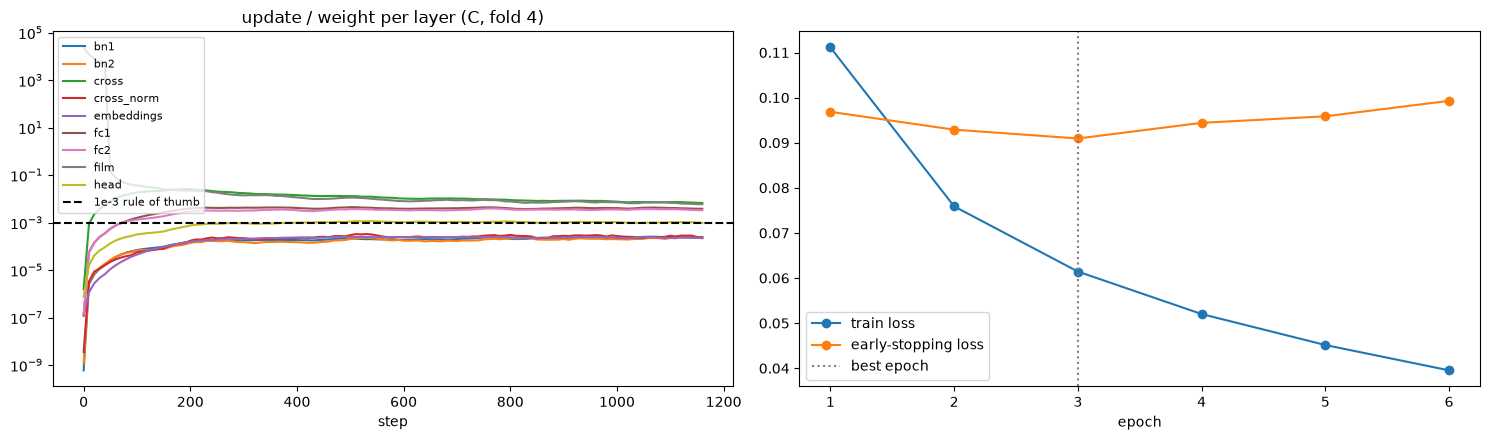

layer
cross_norm    0.000056
embeddings    0.000058
bn2           0.000065
bn1           0.000077
head          0.000328
fc2           0.001438
fc1           0.001981
cross         0.020192
film          0.033706
Name: update ratio, dtype: float64

In [24]:
cfg_c = runs["C: + FiLM"]["cfg"]
tr, va = folds[3]
n_es = len(tr) // 10
_, diag_hist, diag_best, diag_grads, _ = train_model(cfg_c, train_idx[tr[:-n_es]], train_idx[tr[-n_es:]], log_grads=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for layer, g in diag_grads.groupby("layer"):
    if g["update ratio"].max() > 0:
        axes[0].plot(g["step"], g["update ratio"].rolling(5, min_periods=1).mean(), label=layer)
axes[0].axhline(1e-3, color="black", ls="--", label="1e-3 rule of thumb")
axes[0].set_yscale("log")
axes[0].set_xlabel("step")
axes[0].set_title("update / weight per layer (C, fold 4)")
axes[0].legend(fontsize=8)
axes[1].plot(diag_hist["epoch"], diag_hist["train loss"], "o-", label="train loss")
axes[1].plot(diag_hist["epoch"], diag_hist["es loss"], "o-", label="early-stopping loss")
axes[1].axvline(diag_best, color="gray", ls=":", label="best epoch")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

diag_grads[diag_grads["epoch"] == 0].groupby("layer")["update ratio"].median().sort_values()

The cross and FiLM layers change 20-30 times faster than the dense layers.

In [25]:
run("C + slow LR for cross/FiLM", {**cfg_c, "slow_lr": 0.1})

C + slow LR for cross/FiLM: CV AUC 0.8964, folds [0.8978 0.9005 0.904  0.8835], best epochs [7, 3, 7, 4]


A smaller learning rate for them doesn't help.

## Selection

In [26]:
best_name = max(runs, key=lambda n: runs[n]["aucs"].mean())
run(best_name + " (seed 1)", runs[best_name]["cfg"], seed=1)
print("selected:", best_name)

results = pd.DataFrame({
    "CV AUC": {n: r["aucs"].mean() for n, r in runs.items()},
    "fold std": {n: r["aucs"].std() for n, r in runs.items()},
    "best epochs": {n: r["epochs"] for n, r in runs.items()},
})
results["vs A"] = results["CV AUC"] - results.loc["A: MLP + embeddings", "CV AUC"]
results.round(4)

A, RAdamW, no warm-up (seed 1): CV AUC 0.9045, folds [0.9033 0.9119 0.9133 0.8896], best epochs [9, 8, 12, 8]
selected: A, RAdamW, no warm-up


,CV AUC,fold std,best epochs,vs A
A: MLP + embeddings,0.9048,0.0113,"[8, 6, 6, 7]",0.0000
B: + cross,0.8986,0.0101,"[4, 3, 4, 3]",-0.0062
C: + FiLM,0.8989,0.0105,"[4, 3, 3, 3]",-0.0059
D: + aux losses,0.8992,0.0093,"[4, 3, 4, 3]",-0.0056
"A, AdamW",0.9047,0.0124,"[7, 4, 6, 4]",-0.0001
"A, RAdamW, no warm-up",0.9068,0.0098,"[7, 6, 6, 7]",0.0021
"A, AdamW, no warm-up",0.9024,0.0113,"[7, 4, 7, 4]",-0.0024
"A, He init",0.9025,0.0124,"[11, 13, 9, 14]",-0.0022
"A, Xavier init",0.9029,0.0118,"[11, 10, 9, 14]",-0.0019
A + lr 1e-3,0.9043,0.0077,"[10, 7, 6, 7]",-0.0005


The best config is the plain MLP with `RAdamW` without warm-up. Seed noise is about 0.002.

## Training curves

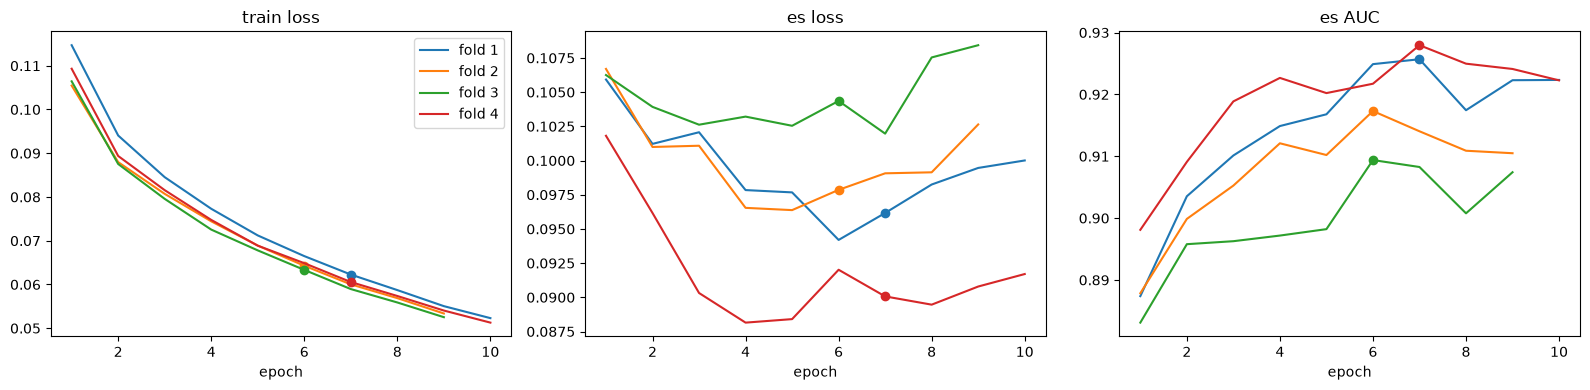

In [27]:
hist = runs[best_name]["hist"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for fold, h in hist.groupby("fold"):
    best = runs[best_name]["epochs"][fold - 1]
    for ax, col in zip(axes, ["train loss", "es loss", "es AUC"]):
        line = ax.plot(h["epoch"], h[col], label=f"fold {fold}")[0]
        ax.plot(best, h.loc[h["epoch"] == best, col], "o", color=line.get_color())
        ax.set_title(col)
        ax.set_xlabel("epoch")
axes[0].legend()
plt.tight_layout()
plt.show()

The last time block is the hardest.

## Final model

In [28]:
n_epochs = int(np.median(runs[best_name]["epochs"]))
print("epochs:", n_epochs)

seed_preds = {}
for seed in [0, 1, 2]:
    model, _, _, grads, hist_log = train_model(runs[best_name]["cfg"], train_idx, epochs=n_epochs, seed=seed, log_grads=(seed == 0))
    seed_preds[f"nn_seed{seed}"] = predict(model, test_idx)
    if seed == 0:
        final_grads = grads
        final_hist = hist_log

p_nn = np.mean(list(seed_preds.values()), axis=0)
pd.DataFrame(seed_preds).rank().corr().round(3)

epochs: 6


,nn_seed0,nn_seed1,nn_seed2
nn_seed0,1.000,0.834,0.833
nn_seed1,0.834,1.000,0.858
nn_seed2,0.833,0.858,1.000


Averaging 3 seeds removes a lot of noise.

## Gradient flow

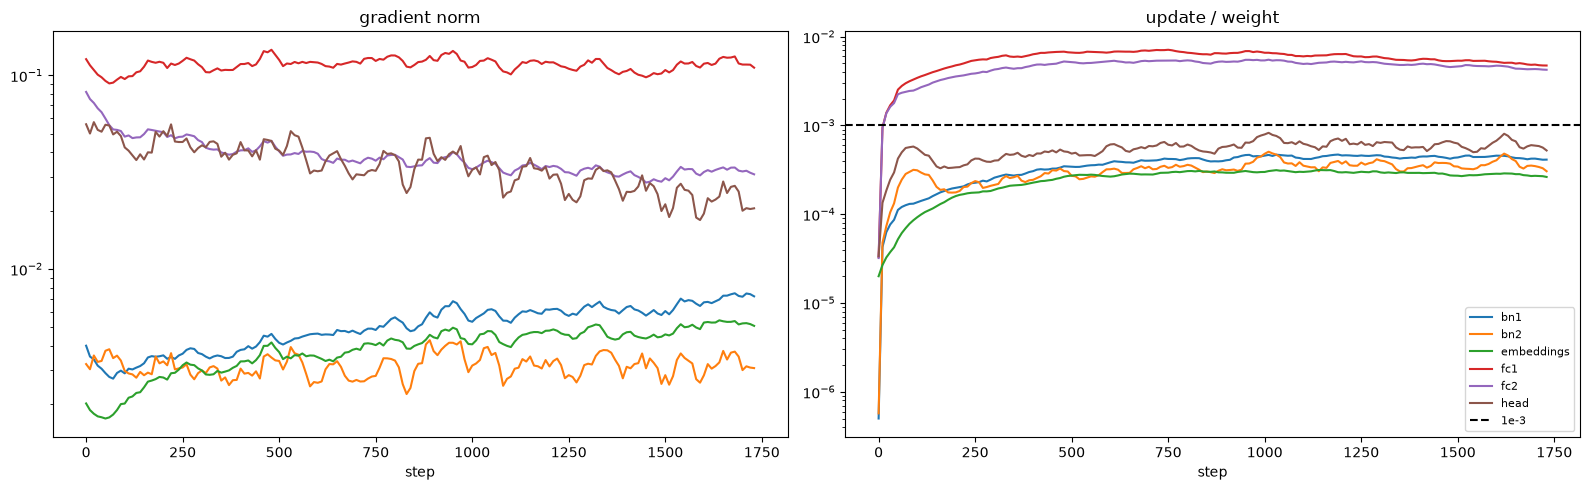

,"grad norm, first epoch","grad norm, last epoch","update ratio, first epoch","update ratio, last epoch"
layer,,,,
bn1,0.003292,0.006873,0.000174,0.000434
bn2,0.002871,0.003003,0.000204,0.000337
embeddings,0.002522,0.005008,0.000126,0.000274
fc1,0.106971,0.108787,0.004258,0.005125
fc2,0.050282,0.032352,0.003308,0.004467
head,0.044271,0.020453,0.000392,0.000553


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for layer, g in final_grads.groupby("layer"):
    axes[0].plot(g["step"], g["grad norm"].rolling(5, min_periods=1).mean(), label=layer)
    axes[1].plot(g["step"], g["update ratio"].rolling(5, min_periods=1).mean(), label=layer)
axes[1].axhline(1e-3, color="black", ls="--", label="1e-3")
axes[0].set_title("gradient norm")
axes[1].set_title("update / weight")
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("step")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

first = final_grads[final_grads["epoch"] == 0].groupby("layer").median()
last = final_grads[final_grads["epoch"] == final_grads["epoch"].max()].groupby("layer").median()
pd.DataFrame({
    "grad norm, first epoch": first["grad norm"],
    "grad norm, last epoch": last["grad norm"],
    "update ratio, first epoch": first["update ratio"],
    "update ratio, last epoch": last["update ratio"],
})

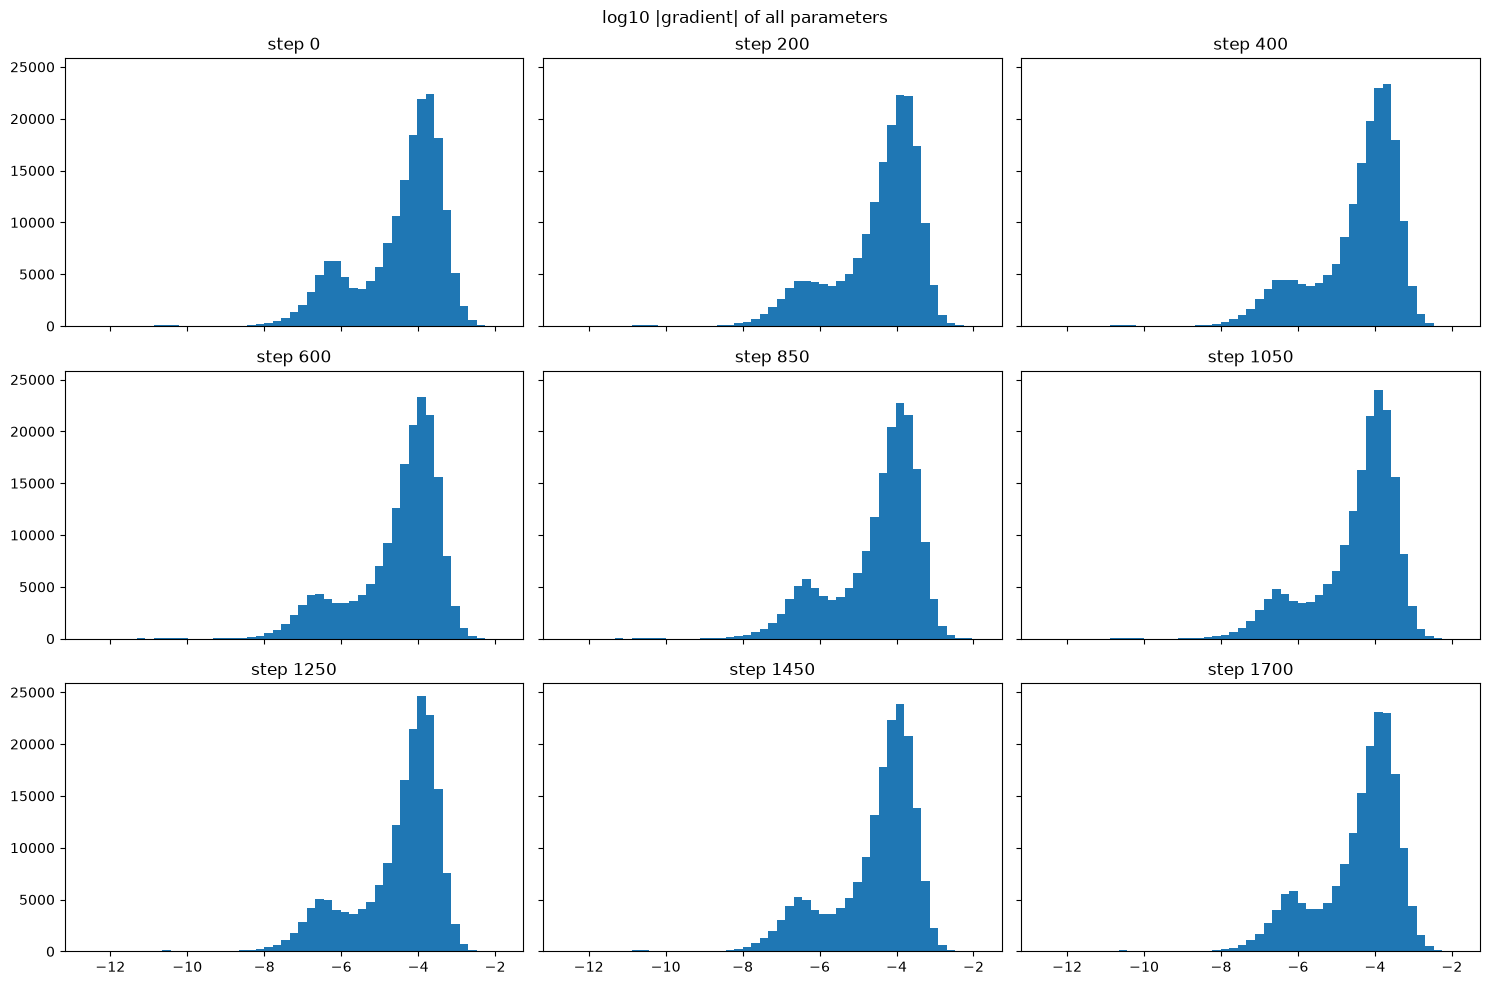

In [30]:
snapshots = np.linspace(0, len(final_hist) - 1, 9).astype(int)
logs = []
for i in snapshots:
    g = final_hist[i][1].numpy()
    logs.append(np.log10(g[g > 0]))
bins = np.linspace(min(l.min() for l in logs), max(l.max() for l in logs), 50)

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
for ax, i, l in zip(axes.flatten(), snapshots, logs):
    ax.hist(l, bins=bins)
    ax.set_title(f"step {final_hist[i][0]}")
fig.suptitle("log10 |gradient| of all parameters")
plt.tight_layout()
plt.show()

Gradients reach every layer, with no spikes or vanishing.

## Neural net vs GBDT

In [31]:
gbdt = pd.read_parquet("../data/interim/gbdt_oof.parquet")
p_gbdt = gbdt["lgb_engineered"].to_numpy()
nn_oof = runs[best_name]["oof"]


def block_auc(score):
    return np.mean([roc_auc_score(y[blocks == g], score[blocks == g]) for g in range(4)])


print("GBDT CV:", round(block_auc(p_gbdt), 4))
print("NN CV:", round(block_auc(nn_oof), 4))

fraud = y == 1
rank_all = pd.Series(p_gbdt).rank().corr(pd.Series(nn_oof).rank())
rank_fraud = pd.Series(p_gbdt[fraud]).rank().corr(pd.Series(nn_oof[fraud]).rank())
print("rank correlation, all rows:", round(rank_all, 3), "fraud rows:", round(rank_fraud, 3))

blend = (pd.Series(p_gbdt).rank(pct=True) + pd.Series(nn_oof).rank(pct=True)).to_numpy()
print("50/50 rank average CV:", round(block_auc(blend), 4))

GBDT CV: 0.9345
NN CV: 0.9068
rank correlation, all rows: 0.706 fraud rows: 0.852


50/50 rank average CV: 0.9304


The neural net is worse than GBDT (0.907 vs 0.935), but ranks transactions differently.

## Is it good enough?

In [32]:
def recall_at_fpr(y_true, score, max_fpr):
    fpr, tpr, _ = roc_curve(y_true, score)
    return tpr[fpr <= max_fpr].max()


def metrics(y_true, score, amt):
    top = np.argsort(-score)[:int(0.01 * len(score))]
    return {
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "Recall @ FPR=1%": recall_at_fpr(y_true, score, 0.01),
        "Precision @ top 1%": y_true[top].mean(),
        "$ recall @ top 1%": (amt[top] * y_true[top]).sum() / (amt * y_true).sum(),
        "log loss": log_loss(y_true, score),
        "mean predicted": score.mean(),
    }


print("real fraud rate:", round(y.mean(), 4))
pd.DataFrame({
    "neural net": metrics(y, nn_oof, amount),
    "GBDT": metrics(y, p_gbdt, amount),
}).round(4)

real fraud rate: 0.035


,neural net,GBDT
ROC-AUC,0.9038,0.9334
PR-AUC,0.5222,0.6314
Recall @ FPR=1%,0.4567,0.5438
Precision @ top 1%,0.8359,0.9355
$ recall @ top 1%,0.1763,0.1888
log loss,0.0964,0.0796
mean predicted,0.0320,0.0287


In [33]:
rows = []
for prod in ["W", "C", "R", "H", "S"]:
    m = product == prod
    rows.append({"ProductCD": prod,
                 "neural net": roc_auc_score(y[m], nn_oof[m]),
                 "GBDT": roc_auc_score(y[m], p_gbdt[m])})
pd.DataFrame(rows).set_index("ProductCD").round(4)

,neural net,GBDT
ProductCD,,
W,0.8688,0.9133
C,0.9073,0.9312
R,0.9394,0.9568
H,0.8833,0.9219
S,0.9040,0.9364


It is worse than GBDT on every metric, but better calibrated.

## Save predictions

In [34]:
pd.DataFrame({"TransactionID": transaction_id[train_idx], "isFraud": y, "nn": nn_oof}).to_parquet(
    "../data/interim/dl_oof.parquet", index=False)
pd.DataFrame({"TransactionID": transaction_id[test_idx], "nn": p_nn, **seed_preds}).to_parquet(
    "../data/interim/dl_test.parquet", index=False)
results.assign(selected=results.index == best_name).to_csv("../data/interim/05_runs.csv")

os.makedirs("../submissions", exist_ok=True)
pd.DataFrame({"TransactionID": transaction_id[test_idx], "isFraud": p_nn}).to_csv("../submissions/05_nn.csv", index=False)

## Summary

- `RAdamW` matches PyTorch and works without warm-up.
- He / Xavier init don't help.
- Cross, FiLM and auxiliary losses make the model worse, so the final model is a plain MLP.
- The neural net is worse than GBDT but ranks transactions differently.